# Ekman Emotion Classification — Single-Stage E2E

**Pipeline:**
```
Text → [7-class multi-label] → anger / disgust / fear / joy / sadness / surprise / neutral
```


**Output structure:**
```
<run_base_dir>/run_e2e/
  roberta/                ← first run
    checkpoints/best.pth
    logs/training_log.csv
    logs/config.txt
    results/              ← report, metrics, charts
  roberta_2/              ← second run (no overwrite)
```

## 0. Setup

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
!git clone https://github.com/convitom/NLP_Emotion_Group_14.git

Cloning into 'NLP_Emotion_Group_14'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (270/270), done.
remote: Compressing objects: 100% (230/230), done.
remote: Total 578 (delta 99), reused 154 (delta 31), pack-reused 308 (from 1)
Receiving objects: 100% (578/578), 11.36 MiB | 28.37 MiB/s, done.
Resolving deltas: 100% (251/251), done.


In [ ]:
!pip install torch transformers scikit-learn pandas numpy matplotlib tqdm nlpaug pyyaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 13.0 MB/s eta 0:00:00


In [ ]:
import os, sys
import torch

PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
cd /content/NLP_Emotion_Group_14/end-to-end

/content/NLP_Emotion_Group_14/end-to-end


In [ ]:
from src.utils import load_config

CONFIG_PATH = 'config/config.yaml'
cfg = load_config(CONFIG_PATH)

print(f"run_base_dir : {cfg['run_base_dir']}")
print(f"Model        : {cfg['e2e']['model']['name']}")
print(f"Loss         : {cfg['e2e']['training']['loss']}")

run_base_dir : /content/drive/MyDrive
Model        : electra
Loss         : asymmetric


## 1. Data Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(os.path.join(cfg['data']['data_dir'], cfg['data']['train_file']))
emotions = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
counts   = df[emotions].sum().sort_values(ascending=False)

n_emotion = (df[emotions].sum(axis=1) > 0).sum()
n_neutral = len(df) - n_emotion

print(f'Total samples : {len(df):,}')
print(f'has_emotion   : {n_emotion:,} ({n_emotion/len(df)*100:.1f}%)')
print(f'neutral       : {n_neutral:,} ({n_neutral/len(df)*100:.1f}%)')
print(f'\nClass counts (all 7, sorted):')
all_counts = dict(counts)
all_counts['neutral'] = n_neutral
for name, c in sorted(all_counts.items(), key=lambda x: -x[1]):
    print(f'  {name:<12}: {int(c):>6} ')

Total samples : 50,248
has_emotion   : 35,751 (71.1%)
neutral       : 14,497 (28.9%)

Class counts (all 7, sorted):
  joy         :  19794 
  neutral     :  14497 
  anger       :   7813 
  surprise    :   5418 
  sadness     :   5392 
  disgust     :   3366 
  fear        :   1941 


## 2. Training


In [ ]:
import yaml

CONFIG_PATH = 'config/config.yaml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# Output

cfg['run_base_dir'] = "/content/drive/MyDrive"

# Data
cfg['data']['data_dir']   = "data/"
cfg['data']['train_file'] = "data1_train.csv"
cfg['data']['val_file']   = "data1_val.csv"
cfg['data']['test_file']  = "data1_test.csv"

cfg['data']['auto_split']  = False
cfg['data']['val_ratio']   = 0.10
cfg['data']['test_ratio']  = 0.10
cfg['data']['max_length']  = 128
cfg['data']['seed']        = 42
cfg['data']['num_workers'] = 0

# Model
cfg['e2e']['model']['name']    = "electra"  # roberta / electra / bert
cfg['e2e']['model']['dropout'] = 0.2

# Training
cfg['e2e']['training']['epochs']                  = 20
cfg['e2e']['training']['batch_size']              = 32   # giảm xuống 16 nếu OOM
cfg['e2e']['training']['lr']                      = 2.0e-5
cfg['e2e']['training']['weight_decay']            = 0.05
cfg['e2e']['training']['optimizer']               = "adamw"
cfg['e2e']['training']['scheduler']               = "cosine_warmup"
cfg['e2e']['training']['warmup_ratio']            = 0.10
cfg['e2e']['training']['early_stopping_patience'] = 5
cfg['e2e']['training']['threshold']               = 0.5
cfg['e2e']['training']['training_mode']           = "finetune"
cfg['e2e']['training']['llrd_decay_rate']         = 0.8
cfg['e2e']['training']['loss']                    = "asymmetric"


# ASL parameter
cfg['e2e']['training']['asl_gamma_pos']           = 0.0
cfg['e2e']['training']['asl_gamma_neg']           = 2.0
cfg['e2e']['training']['asl_clip']                = 0.05

# Synonym augmentation
cfg['e2e']['training']['augment']                 = True

# Inference window size
cfg['e2e']['training']['inference_window']        = 1


# Save overrides back to yaml so train.py reads them
with open(CONFIG_PATH, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

print(f"Model  : {cfg['e2e']['model']['name']}")
print(f"Epochs : {cfg['e2e']['training']['epochs']}")
print(f"Batch  : {cfg['e2e']['training']['batch_size']}")
print(f"Loss   : {cfg['e2e']['training']['loss']}")

Model  : electra
Epochs : 20
Batch  : 32
Loss   : asymmetric


In [ ]:
from src.train import train

result = train(config_path=CONFIG_PATH)

RUN_DIR = result['run_dir']
print(f'\nRun directory: {RUN_DIR}')
print(f'Best epoch   : {result["best_epoch"]}')
for k, v in result['best_metrics'].items():
    print(f'  {k}: {v:.4f}')


  New run  : electra_2
  Path     : /content/drive/MyDrive/run_e2e/electra_2
[train] Device=cuda  AMP=True (float16)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...


[WARNING] NaN/Inf gradient — skipping batch, resetting scaler
Epoch  16/20  tr_loss=0.0173  val_loss=0.7649  micro_f1=0.6694  macro_f1=0.6271  w_f1=0.6690  lr=2.35e-06  [492s]


Epoch 17/20 [train]:   0%|          | 0/1744 [00:00<?, ?batch/s]

Epoch  17/20  tr_loss=0.0154  val_loss=0.7681  micro_f1=0.6709  macro_f1=0.6282  w_f1=0.6702  lr=1.35e-06  [492s]


Epoch 18/20 [train]:   0%|          | 0/1744 [00:00<?, ?batch/s]


[WARNING] NaN/Inf gradient — skipping batch, resetting scaler
Epoch  18/20  tr_loss=0.0141  val_loss=0.7703  micro_f1=0.6687  macro_f1=0.6276  w_f1=0.6677  lr=6.08e-07  [492s]
[train] Early stopping at epoch 18 (5 consecutive epochs without improvement).

[train] Done — best val_macro_f1=0.6305 @ epoch 13
        micro_f1=0.6711
        macro_f1=0.6305
        weighted_f1=0.6720
[train] Log  → /content/drive/MyDrive/run_e2e/electra_2/logs/training_log.csv

Run directory: /content/drive/MyDrive/run_e2e/electra_2
Best epoch   : 13
  micro_f1: 0.6711
  macro_f1: 0.6305
  weighted_f1: 0.6720


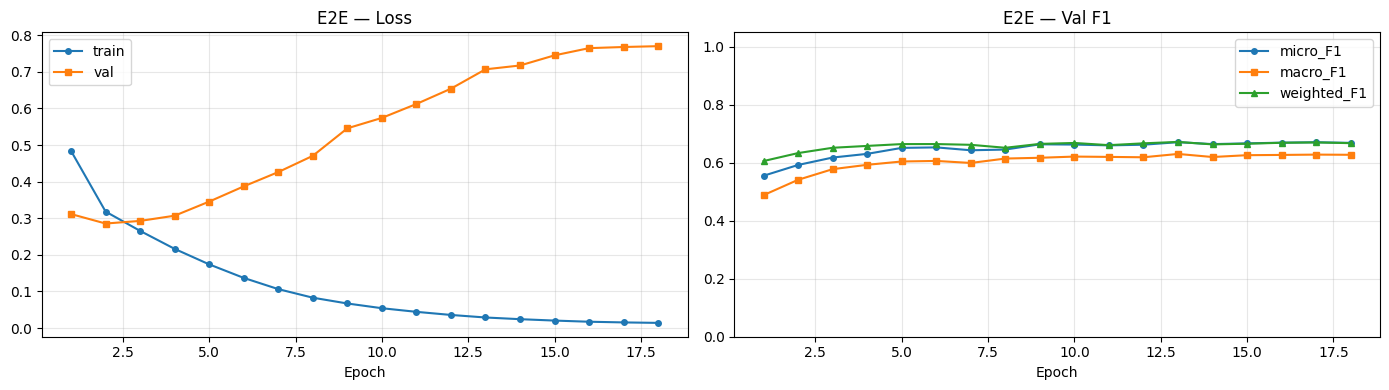

In [ ]:
log = pd.read_csv(result['log_path'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(log.epoch, log.train_loss, label='train', marker='o', ms=4)
ax1.plot(log.epoch, log.val_loss,   label='val',   marker='s', ms=4)
ax1.set_title('E2E — Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(log.epoch, log.val_micro_f1,    label='micro_F1',    marker='o', ms=4)
ax2.plot(log.epoch, log.val_macro_f1,    label='macro_F1',    marker='s', ms=4)
ax2.plot(log.epoch, log.val_weighted_f1, label='weighted_F1', marker='^', ms=4)
ax2.set_title('E2E — Val F1')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Evaluate on Test Set

In [ ]:
from src.test import evaluate

metrics = evaluate(config_path=CONFIG_PATH, run_dir=RUN_DIR)

print(f'Micro  F1    : {metrics["micro_f1"]:.4f}')
print(f'Macro  F1    : {metrics["macro_f1"]:.4f}')
print(f'Weighted F1  : {metrics["weighted_f1"]:.4f}')
print(f'Hamming Loss : {metrics["hamming"]:.4f}')
print(f'Subset Acc   : {metrics["subset_accuracy"]:.4f}')


  Evaluation — 7 Classes
  Inference: sentence splitting + context window=1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
electra.embeddings_project.bias                   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[build_model] finetune — full end-to-end fine-tuning
[test] Loaded checkpoint  epoch=13  val_macro_f1=0.6305

[DataLoader] Running median-based synonym augmentation (nlpaug)...


Streaming output truncated to the last 5000 lines.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_dat

[Augmentation] class=disgust      n_c=  3366 → +2052 samples (target median=5418)


Streaming output truncated to the last 5000 lines.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_dat

[Augmentation] class=fear         n_c=  1941 → +3477 samples (target median=5418)
[Augmentation] class=sadness      n_c=  5392 → +26 samples (target median=5418)
[DataLoader] Training set after augmentation: 55803 samples

[DataLoader] pos_weight (post-augmentation):
    anger       : 4.63
    disgust     : 7.82
    fear        : 8.77
    joy         : 1.72
    sadness     : 6.75
    surprise    : 8.84
    neutral     : 2.85
[DataLoader] backbone=electra  |  pretrained=google/electra-base-discriminator
[DataLoader] Train=55803  Val=6312  Test=8686

[test] Sentence-level inference on validation set...
[test] Per-class optimal thresholds (val):
  anger       : t=0.75  val_F1=0.6017
  disgust     : t=0.80  val_F1=0.6406
  fear        : t=0.90  val_F1=0.6519
  joy         : t=0.90  val_F1=0.8159
  sadness     : t=0.90  val_F1=0.6317
  surprise    : t=0.90  val_F1=0.5534
  neutral     : t=0.40  val_F1=0.6057

[test] Sentence-level inference on test set...

  Micro  F1    : 0.6946
  Macro  F

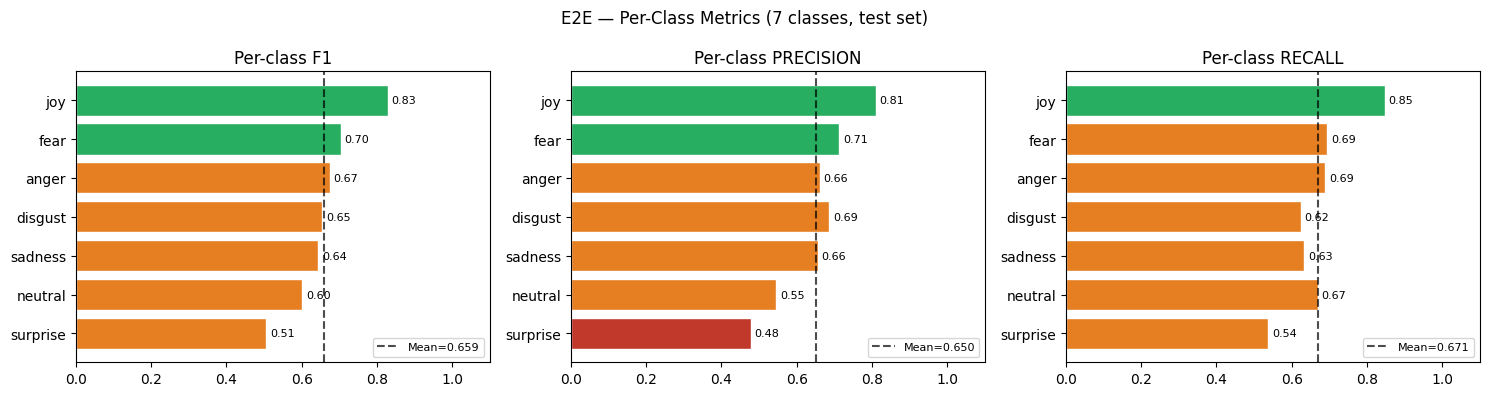

,threshold,precision,recall,f1,support
class,,,,,
surprise,0.90,0.4783,0.5375,0.5062,800
neutral,0.40,0.5452,0.6691,0.6009,1883
sadness,0.90,0.6559,0.6331,0.6443,1412
disgust,0.80,0.6862,0.6243,0.6538,1219
anger,0.75,0.6615,0.6889,0.6749,1787
fear,0.90,0.7135,0.6938,0.7035,578
joy,0.90,0.8096,0.8470,0.8279,3699


In [ ]:
pc = pd.read_csv(os.path.join(metrics['out_dir'], 'per_class.csv'))
pc = pc.set_index('class').sort_values('f1')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['f1', 'precision', 'recall']):
    colors = ['#c0392b' if v < 0.5 else '#e67e22' if v < 0.7 else '#27ae60'
              for v in pc[col]]
    bars = ax.barh(pc.index, pc[col], color=colors, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(f'Per-class {col.upper()}')
    ax.axvline(pc[col].mean(), color='black', linestyle='--', alpha=0.7,
               label=f'Mean={pc[col].mean():.3f}')
    ax.legend(fontsize=8)
    for bar, v in zip(bars, pc[col]):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=8)

plt.suptitle('E2E — Per-Class Metrics (7 classes, test set)', fontsize=12)
plt.tight_layout()
plt.show()
display(pc)


─── PR Curves ───


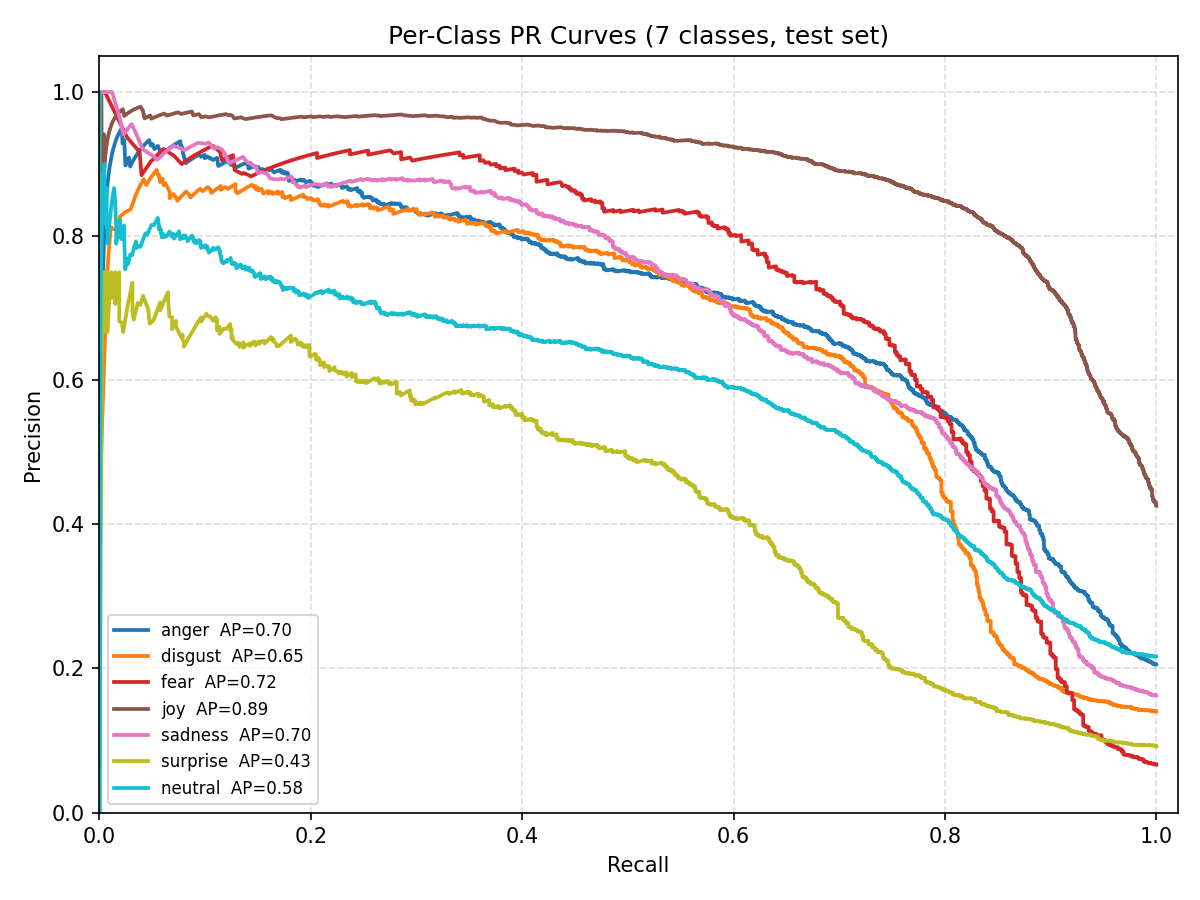


─── Aggregated Confusion Matrix ───


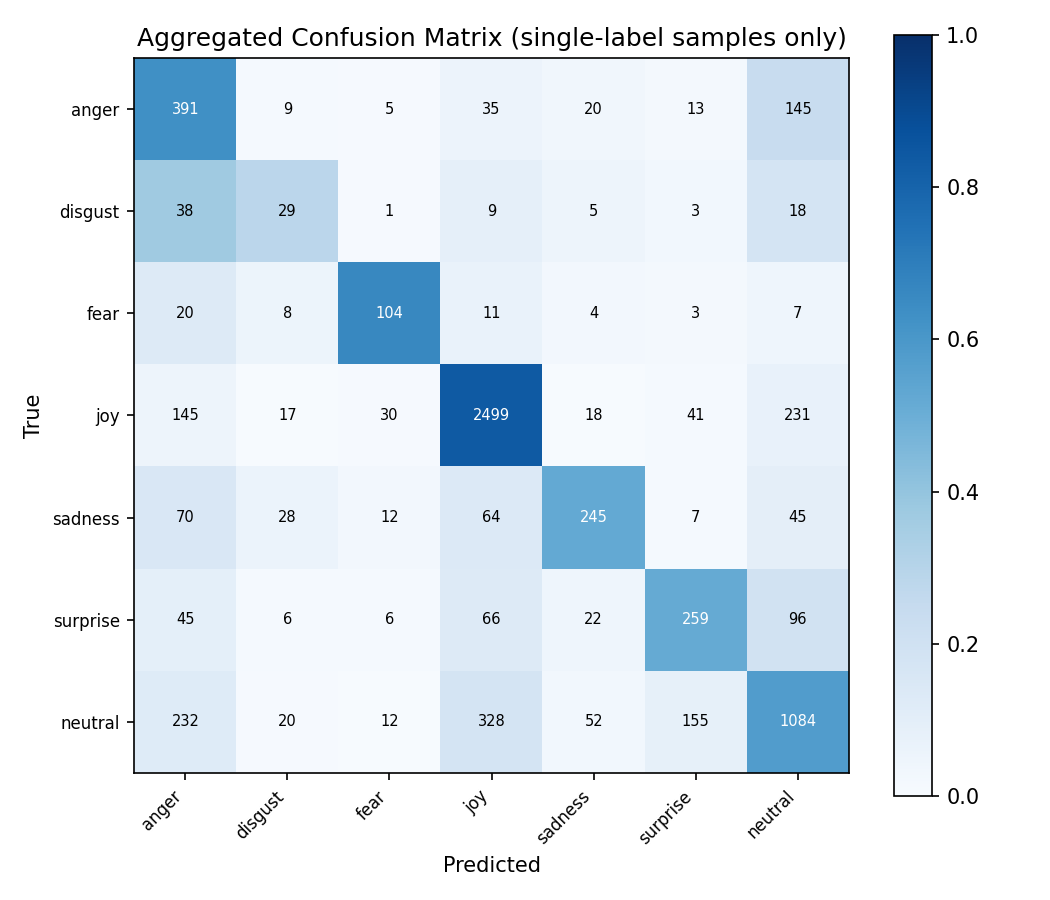


─── Per-Class Confusion Matrices ───


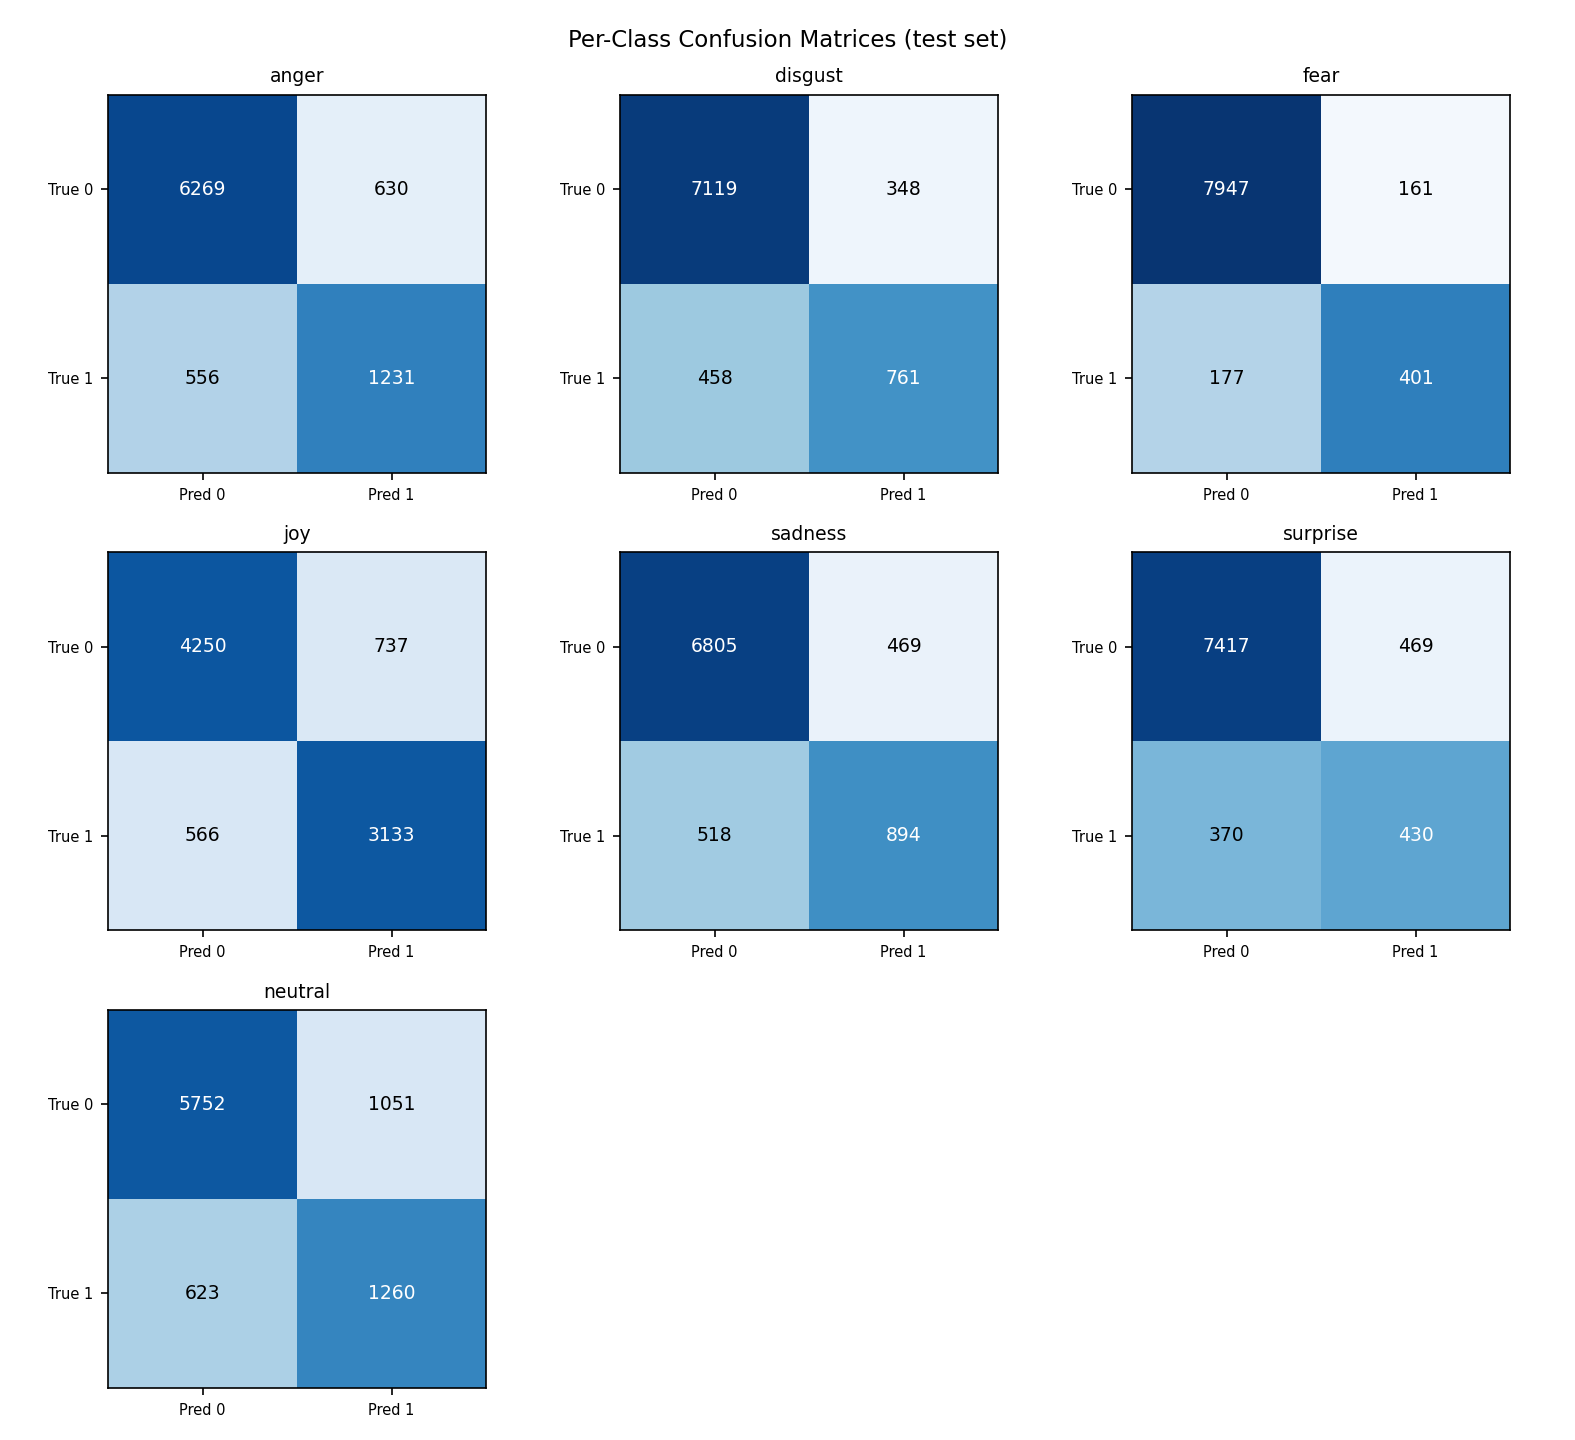


─── Probability Heatmap ───


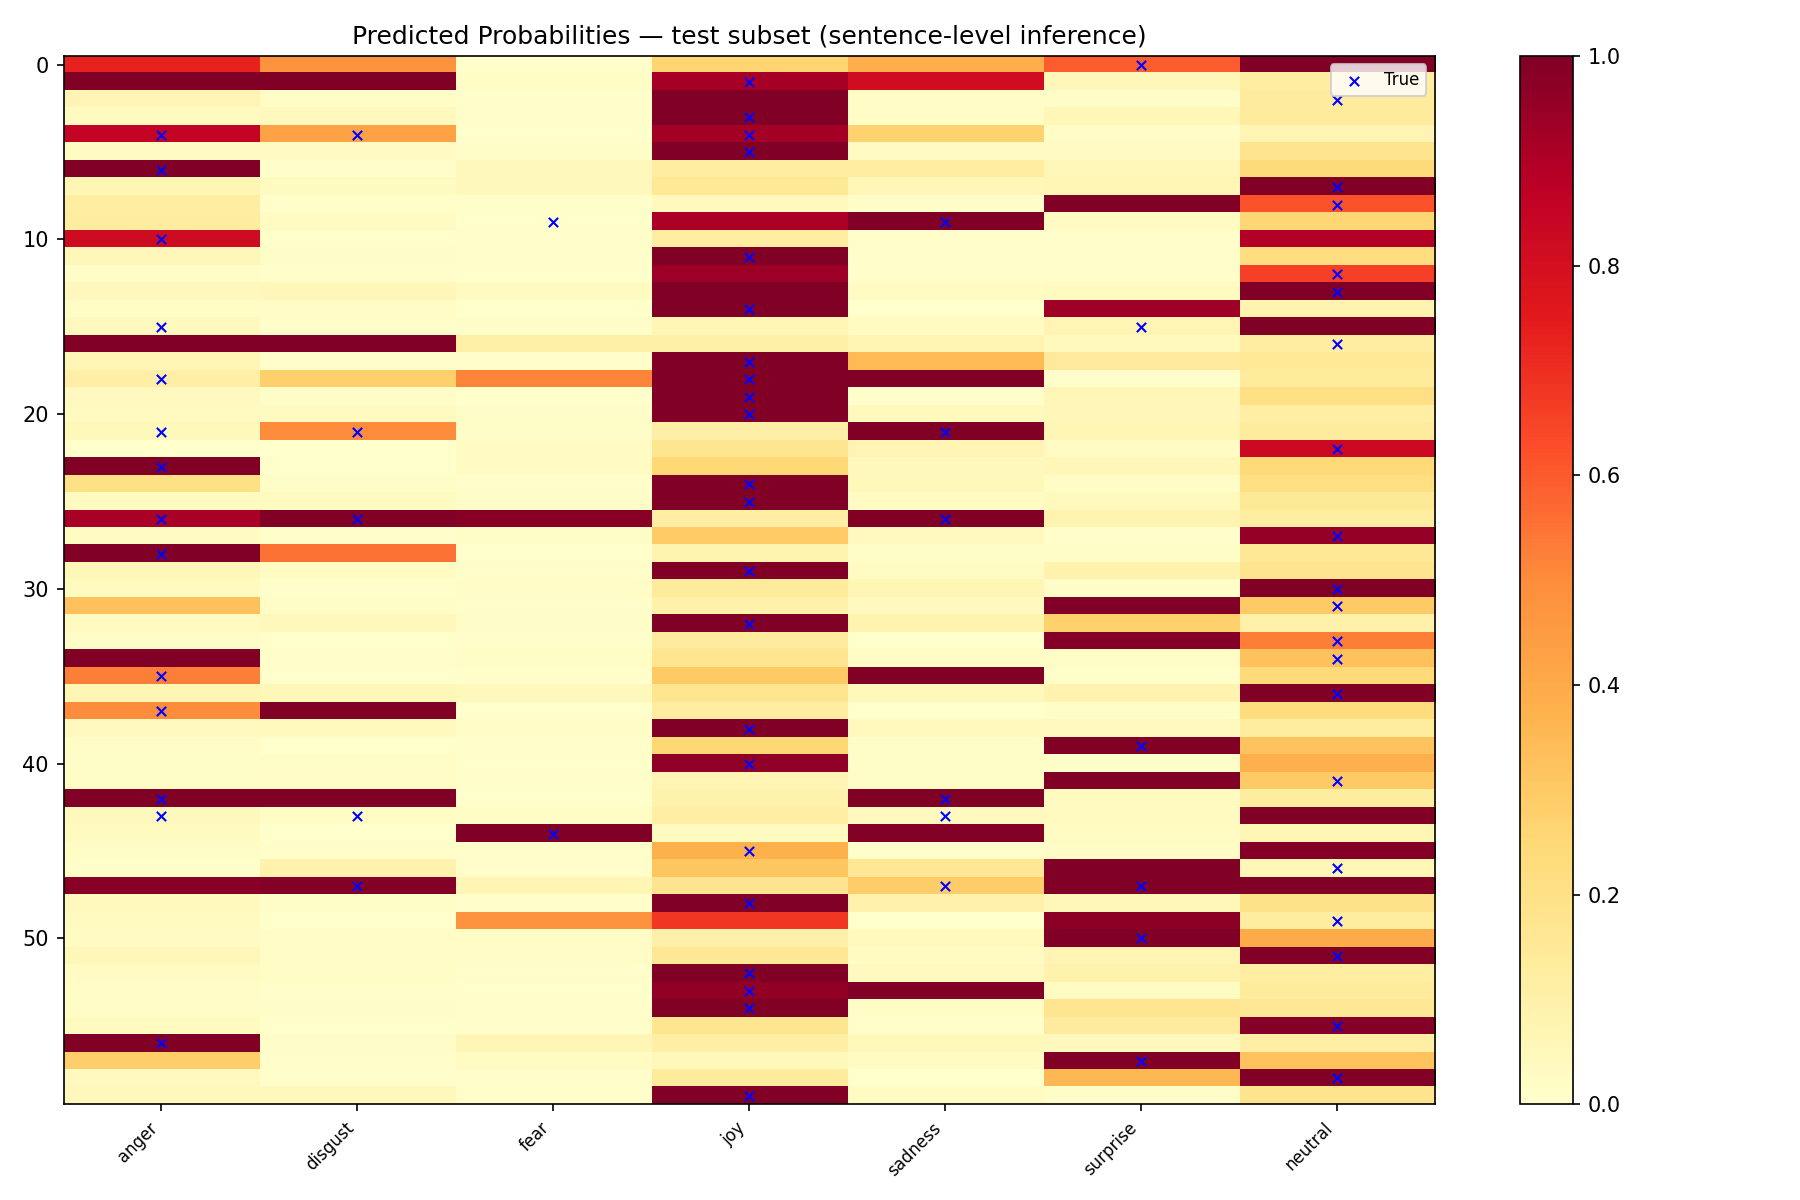


─── Optimal Thresholds ───


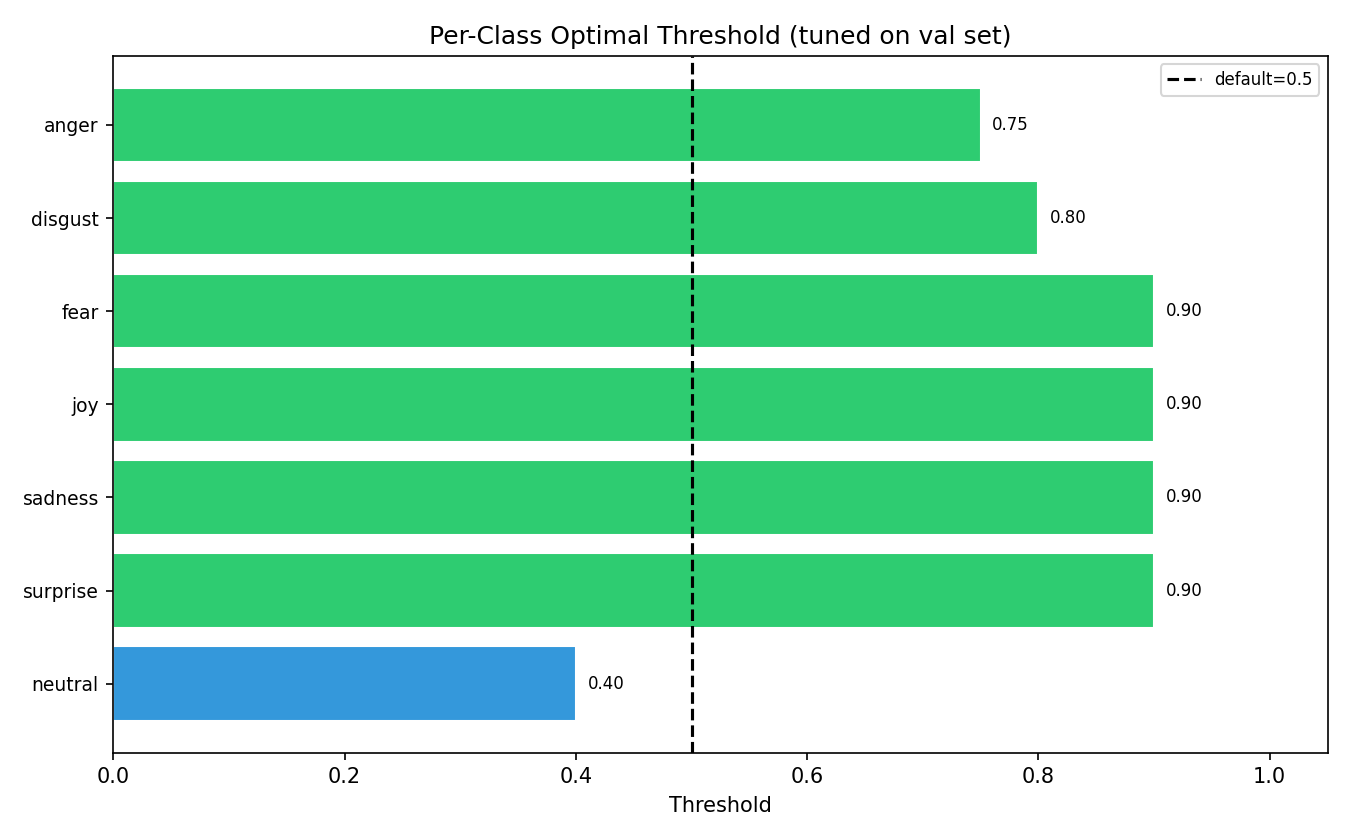

In [ ]:
from IPython.display import Image, display as ipy_display

plots = [
    ('pr_curve.png',            'PR Curves'),
    ('confusion_aggregate.png', 'Aggregated Confusion Matrix'),
    ('confusion.png',           'Per-Class Confusion Matrices'),
    ('heatmap.png',             'Probability Heatmap'),
    ('thresholds.png',          'Optimal Thresholds'),
]

for fname, title in plots:
    path = os.path.join(metrics['out_dir'], fname)
    if os.path.isfile(path):
        print(f'\n─── {title} ───')
        ipy_display(Image(path))

## 4. Results Summary

In [ ]:
print('=' * 62)
print(f'  Run : {result["run_name"]}')
print(f'  Dir : {RUN_DIR}')
print('=' * 62)
print(f'\n E2E — 7 Classes ({cfg["e2e"]["model"]["name"]})')
print(f'   Micro F1     : {metrics["micro_f1"]:.4f}')
print(f'   Macro F1     : {metrics["macro_f1"]:.4f}')
print(f'   Weighted F1  : {metrics["weighted_f1"]:.4f}')
print(f'   Hamming Loss : {metrics["hamming"]:.4f}')
print(f'   Subset Acc   : {metrics["subset_accuracy"]:.4f}')
print('=' * 62)

print('\n Per-class F1:')
pc_sorted = pc.sort_values('f1', ascending=False)
for name, row in pc_sorted.iterrows():
    bar = '█' * int(row['f1'] * 20)
    print(f'  {name:<12}: {row["f1"]:.4f}  {bar}')

  Run : electra_2
  Dir : /content/drive/MyDrive/run_e2e/electra_2

 E2E — 7 Classes (electra)
   Micro F1     : 0.6946
   Macro F1     : 0.6588
   Weighted F1  : 0.6959
   Hamming Loss : 0.1173
   Subset Acc   : 0.5284

 Per-class F1:
  joy         : 0.8279  ████████████████
  fear        : 0.7035  ██████████████
  anger       : 0.6749  █████████████
  disgust     : 0.6538  █████████████
  sadness     : 0.6443  ████████████
  neutral     : 0.6009  ████████████
  surprise    : 0.5062  ██████████


## 5. Inference on New Texts

In [ ]:
import torch
from src.train import build_model
from src.dataloader import BACKBONE_REGISTRY, CLASS_NAMES
from transformers import AutoTokenizer

model_name = cfg['e2e']['model']['name']
ckpt = torch.load(os.path.join(RUN_DIR, 'checkpoints', 'best.pth'),
                  map_location=device, weights_only=False)

model = build_model(cfg['e2e'], num_labels=ckpt['num_labels']).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

tokenizer = AutoTokenizer.from_pretrained(BACKBONE_REGISTRY[model_name]['pretrained'])
best_ts   = metrics['best_thresholds']   # per-class thresholds từ val set
max_len   = cfg['data']['max_length']

def predict(text):
    enc = tokenizer(text, max_length=max_len, padding='max_length',
                    truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = model(enc['input_ids'].to(device),
                       enc['attention_mask'].to(device))
    probs = torch.sigmoid(logits).float().cpu().numpy()[0]
    preds = (probs >= best_ts).astype(int)
    detected = {CLASS_NAMES[i]: float(probs[i])
                for i in range(len(CLASS_NAMES)) if preds[i] == 1}
    if not detected:
        top = CLASS_NAMES[int(probs.argmax())]
        detected = {top: float(probs.max())}
    print(f'  [{text[:70]}]')
    for name, p in sorted(detected.items(), key=lambda x: -x[1]):
        print(f'    → {name:<12}: {p:.3f}  {"█"*int(p*20)}')
    print()

print('Model loaded. Ready for inference.')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
electra.embeddings_project.bias                   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[build_model] finetune — full end-to-end fine-tuning
Model loaded. Ready for inference.


In [ ]:
test_sentences = [
    "I am so happy today, everything went perfectly!",
    "This is absolutely disgusting, I can't believe they did that.",
    "I'm really scared about what might happen next.",
    "The weather is nice today.",
    "I feel so angry and disappointed at the same time.",
    "Wow, I did not expect that at all — completely shocked!",
    "I miss her so much, it still hurts.",
]

for s in test_sentences:
    predict(s)

  [I am so happy today, everything went perfectly!]
    → joy         : 1.000  ███████████████████

  [This is absolutely disgusting, I can't believe they did that.]
    → disgust     : 1.000  ███████████████████

  [I'm really scared about what might happen next.]
    → fear        : 1.000  ███████████████████

  [The weather is nice today.]
    → joy         : 1.000  ███████████████████

  [I feel so angry and disappointed at the same time.]
    → sadness     : 1.000  ███████████████████
    → anger       : 0.995  ███████████████████

  [Wow, I did not expect that at all — completely shocked!]
    → surprise    : 1.000  ███████████████████

  [I miss her so much, it still hurts.]
    → sadness     : 1.000  ███████████████████

